<a href="https://colab.research.google.com/github/sonalsd/Statistical-Data-Analysis-of-CryptoCurrency/blob/main/SDA%20of%20CryptoCurrency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Crypto Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats

In [ ]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/crypto_combine.csv")

In [ ]:
# Get summary statistics of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crypto  7899 non-null   object 
 1   Date    7899 non-null   object 
 2   Open    7899 non-null   float64
 3   High    7899 non-null   float64
 4   Low     7899 non-null   float64
 5   Close   7899 non-null   float64
dtypes: float64(4), object(2)
memory usage: 370.4+ KB


In [ ]:
df.describe()

,Open,High,Low,Close
count,7899.000000,7899.000000,7899.000000,7899.000000
mean,5479.620176,5623.947143,5324.149024,5480.870398
std,12010.579332,12325.039614,11665.236339,12011.567525
min,0.140000,0.150000,0.120000,0.140000
25%,12.720000,13.410000,12.405000,12.680000
50%,170.910000,176.240000,163.320000,170.890000
75%,3879.000000,3962.000000,3757.000000,3878.935000
max,67802.000000,68925.000000,66112.000000,67802.000000


In [ ]:
df.columns

Index(['Crypto', 'Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [ ]:
# Display the first few rows of the dataset
df.head()

,Crypto,Date,Open,High,Low,Close
0,BTC,12/31/19,7254.0,7309.0,7132.0,7171.0
1,BTC,12/30/19,7402.0,7430.0,7217.0,7254.0
2,BTC,12/29/19,7334.0,7529.0,7295.0,7402.0
3,BTC,12/28/19,7235.0,7359.0,7235.0,7334.0
4,BTC,12/27/19,7208.0,7267.0,7087.0,7235.0


In [ ]:
# Display the last few rows of the dataset
df.tail()

,Crypto,Date,Open,High,Low,Close
7894,XRP,1/5/19,0.36,0.36,0.35,0.36
7895,XRP,1/4/19,0.36,0.36,0.35,0.36
7896,XRP,1/3/19,0.37,0.38,0.35,0.36
7897,XRP,1/2/19,0.36,0.37,0.36,0.37
7898,XRP,1/1/19,0.35,0.36,0.34,0.36


In [ ]:
df.shape

(7899, 6)

In [ ]:
# Data Transformation
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
# Display the first few entries of the 'Date' column
print(df['Date'].head())

<ipython-input-13-2ee6e893f3a4>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


0   2019-12-31
1   2019-12-30
2   2019-12-29
3   2019-12-28
4   2019-12-27
Name: Date, dtype: datetime64[ns]


In [ ]:
# Ensure numerical columns are of appropriate data types
numeric_columns = ['Open', 'Close', 'High', 'Low']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
print("\nData Types of Each Column:")
print(df.dtypes)


Data Types of Each Column:
Crypto            object
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
dtype: object


In [ ]:
# Data Classification - Identifying numerical and categorical features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nNumeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: Index(['Open', 'High', 'Low', 'Close'], dtype='object')
Categorical Columns: Index(['Crypto'], dtype='object')


In [ ]:
# Handling Missing Values
missing_values = df.isnull().sum()
print("Missing Values Before Handling:")
print(missing_values)

if missing_values.sum() == 0:
    print("\n No missing values detected. Proceeding with outlier detection and feature engineering.\n")
else:
    # Fill missing values with median for numerical columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    print("\n Missing Values After Handling:")
    print(df.isnull().sum())

Missing Values Before Handling:
Crypto    0
Date      0
Open      0
High      0
Low       0
Close     0
dtype: int64

 No missing values detected. Proceeding with outlier detection and feature engineering.



In [ ]:
# Data Integration
# Assuming integration involves aggregating data by date across all cryptocurrencies
# Calculate daily mean prices and total volume
daily_data = df.groupby('Date').agg({
    'Open': 'mean',
    'Close': 'mean',
    'High': 'mean',
    'Low': 'mean'
}).reset_index()

# Display the aggregated daily_data DataFrame
print("Aggregated Daily Data:")
print(daily_data.head())

Aggregated Daily Data:
        Date       Open      Close       High        Low
0 2018-01-01  3743.1750  3629.9350  3761.9625  3451.1975
1 2018-01-02  3630.1025  3972.7025  4091.0300  3484.9875
2 2018-01-03  3972.1975  4060.1950  4151.5775  3920.6750
3 2018-01-04  4059.9925  4026.4100  4158.5650  3839.3375
4 2018-01-05  4026.4075  4507.2750  4545.4600  3988.7875


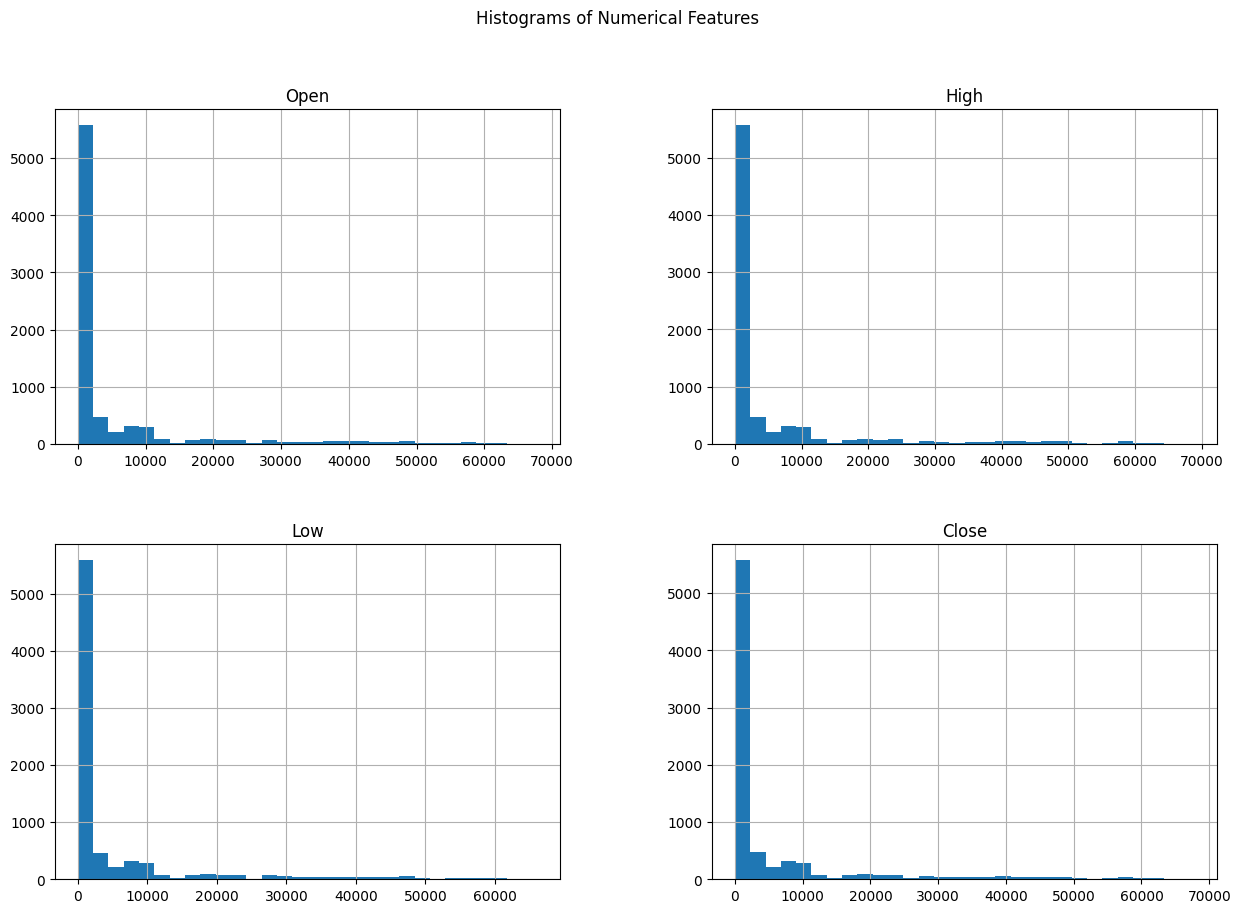

In [ ]:
# Data Visualization
# Histogram of numerical features
df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
plt.show()


**Conclusion from the Histograms:**

**Right-Skewed Distribution:**

All four histograms (Open, High, Low, and Close) exhibit a highly right-skewed distribution.
Most values are concentrated on the lower end, with a small number of very high values.

**Presence of Outliers:**

There are a few data points in the high-price range, indicating extreme values or outliers in the dataset.
These high prices may belong to expensive cryptocurrencies like Bitcoin or Ethereum.

**Majority of Cryptocurrencies Have Low Prices:**

The highest frequency of values appears in the lower price ranges (between 0 and 10,000).
This suggests that most cryptocurrencies in the dataset have a relatively low price, while only a few have exceptionally high prices.

**Consistency Across Open, High, Low, and Close Prices:**

Since all four features (Open, High, Low, and Close) have similar distributions, it indicates price fluctuations remain proportional across different price points.

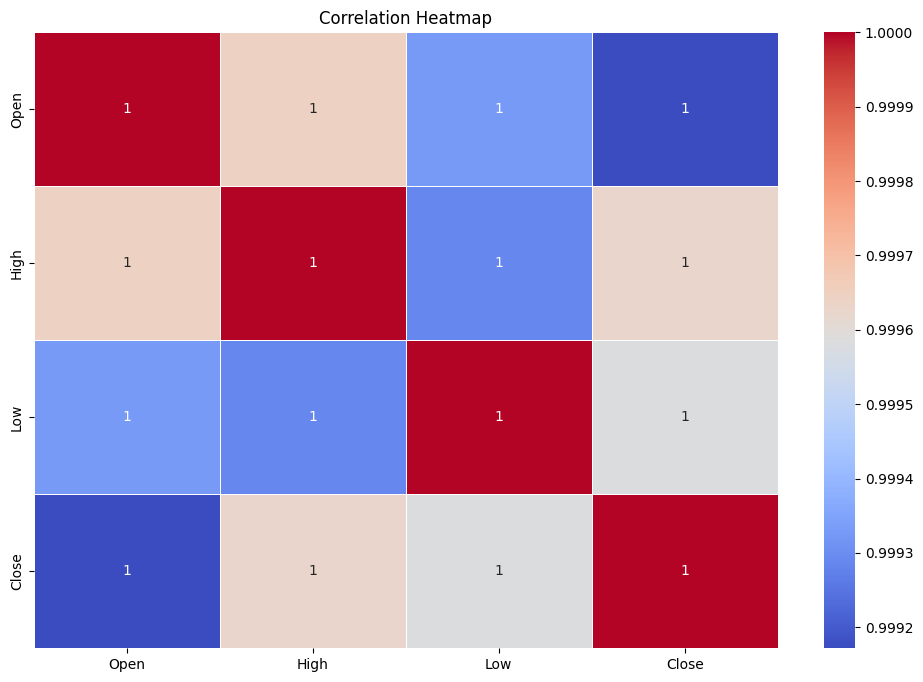

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Conclusion from the Correlation Heatmap:**

**Strong Positive Correlation (≈1.0) Between All Features:**
The heatmap shows that Open, High, Low, and Close prices have nearly perfect correlations (~1.0) with each other.
This suggests that these features move together in a synchronized manner.
Such high correlation is expected in financial time series, as Open, High, Low, and Close prices are closely related.

**Redundant Features for Modeling:**
Since all features are highly correlated, including all of them in a machine learning model might introduce multicollinearity.
Dimensionality reduction techniques (like PCA) or selecting just one of these features (e.g., Close price) might be beneficial for predictive modeling.

**Price Movements are Proportional Across Cryptocurrencies:**
The similar correlation structure suggests that regardless of the cryptocurrency, price changes are proportional across Open, High, Low, and Close values.

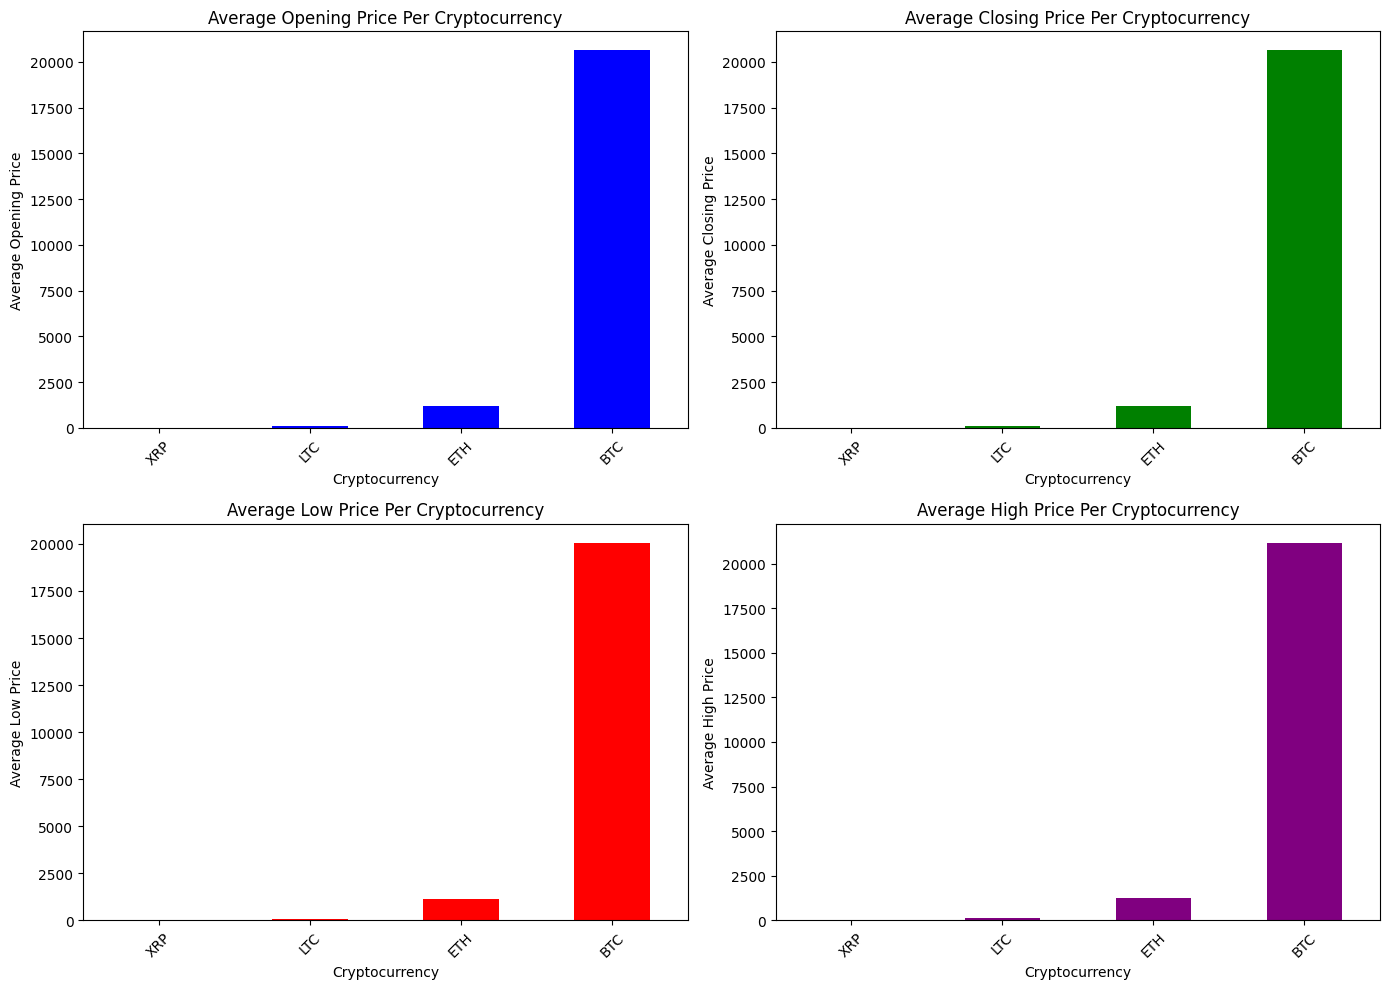

In [ ]:
# Bar Plot for Average opening, closing, high and low Price Per Cryptocurrency

# Define price types and colors
price_types = {'Open': 'blue', 'Close': 'green', 'Low': 'red', 'High': 'purple'}
titles = {'Open': 'Opening', 'Close': 'Closing', 'Low': 'Low', 'High': 'High'}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (price_type, color) in enumerate(price_types.items()):
    df.groupby('Crypto')[price_type].mean().sort_values().plot(kind='bar', color=color, ax=axes[i])
    axes[i].set_title(f'Average {titles[price_type]} Price Per Cryptocurrency')
    axes[i].set_xlabel('Cryptocurrency')
    axes[i].set_ylabel(f'Average {titles[price_type]} Price')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


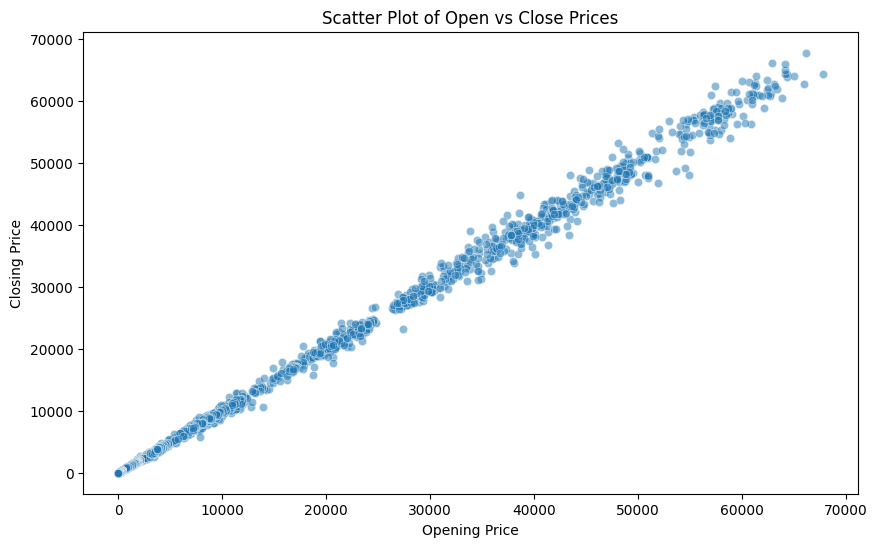

In [ ]:
# Scatter Plot for Opening vs Closing Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Open'], y=df['Close'], alpha=0.5)
plt.title('Scatter Plot of Open vs Close Prices')
plt.xlabel('Opening Price')
plt.ylabel('Closing Price')
plt.show()

**Conclusion from the Scatter Plot (Opening Price vs. Closing Price):**

**Strong Linear Relationship:**
The scatter plot shows a strong positive linear correlation between the Opening Price and Closing Price of cryptocurrencies.
This suggests that the price at which a cryptocurrency opens is a strong predictor of its closing price for the same period.

**Minimal Price Fluctuation:**
The data points are closely clustered around a straight diagonal line, indicating that the opening and closing prices are very similar.
This suggests that cryptocurrency prices do not fluctuate drastically within the same period for most instances.

**Possible Market Stability:**
The consistency in opening and closing prices indicates a relatively stable market trend, at least for the period covered in the dataset.
Large deviations (outliers) could signify volatile trading days, but they appear minimal.

**Predictability in Price Movements:**
Since opening prices are highly correlated with closing prices, simple regression models could effectively predict the closing price based on the opening price.
More advanced techniques could be explored if needed for intraday volatility analysis.

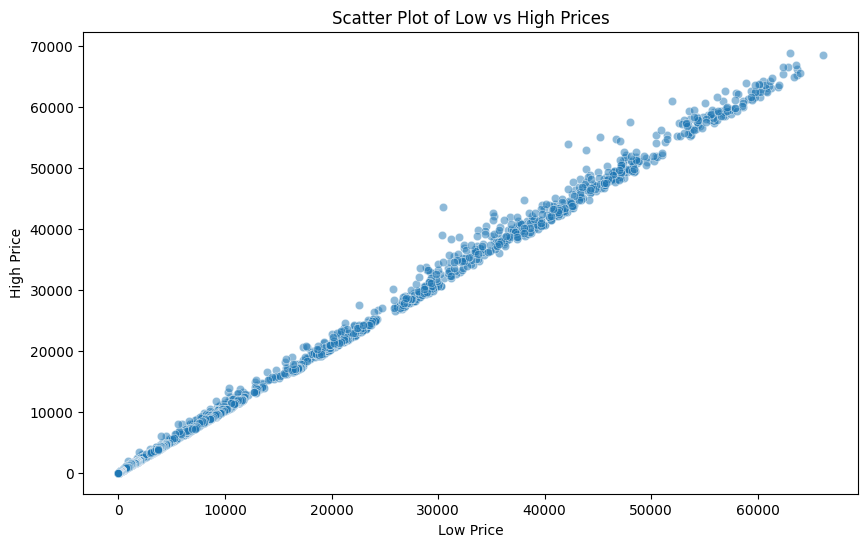

In [ ]:
# Scatter Plot for Low vs High Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Low'], y=df['High'], alpha=0.5)
plt.title('Scatter Plot of Low vs High Prices')
plt.xlabel('Low Price')
plt.ylabel('High Price')
plt.show()

**Conclusion from the Scatter Plot (Low Price vs. High Price):**

**Strong Positive Correlation:**
The scatter plot shows a strong linear relationship between Low Price and High Price of cryptocurrencies.
This means that when the low price of a cryptocurrency increases, its high price also increases proportionally.

**Small Price Fluctuations:**
Most data points lie close to the diagonal, indicating that the difference between low and high prices is relatively small for most cryptocurrencies.
This suggests that daily or periodic price swings are not extreme in most cases.

**Some Outliers Exist:**
A few points deviate slightly from the diagonal, which could indicate higher volatility in those specific cases.
These may correspond to highly volatile cryptocurrencies or sudden price spikes/drops due to market events.

**Price Stability Across Cryptocurrencies:**
Since the relationship between low and high prices is almost perfectly linear, it indicates consistent price behavior across different cryptocurrencies in the dataset.

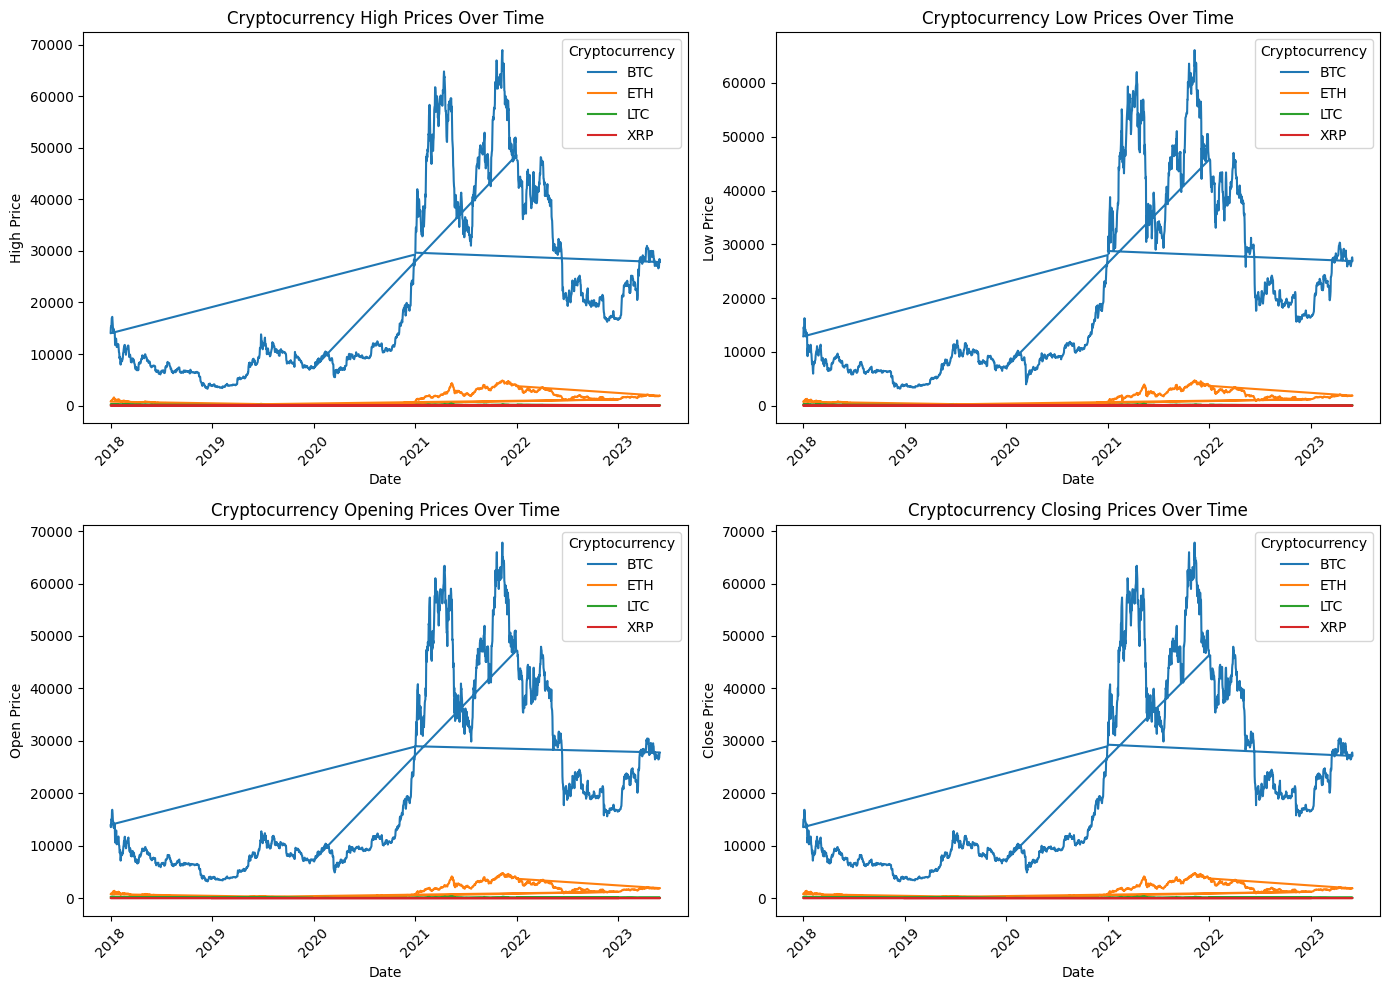

In [ ]:
# Create subplots

# Line Plot for HIgh Prices, Low Prices, Opening and Closing Prices Over Time

# Define price types and titles
price_types = ['High', 'Low', 'Open', 'Close']
titles = ['High Prices', 'Low Prices', 'Opening Prices', 'Closing Prices']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, price_type in enumerate(price_types):
    for crypto in df['Crypto'].unique():
        subset = df[df['Crypto'] == crypto]
        axes[i].plot(subset['Date'], subset[price_type], label=crypto)

    axes[i].set_title(f'Cryptocurrency {titles[i]} Over Time')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(f'{price_type} Price')
    axes[i].legend(title='Cryptocurrency')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


A **pairplot** (from Seaborn) is a powerful visualization tool used to explore relationships between **multiple numerical features** in a dataset. It creates scatter plots for each pair of numerical variables and distributions along the diagonal.

**How to Interpret a Pairplot?**

Tightly clustered points along a diagonal line → Strong correlation.
Randomly scattered points → Weak or no correlation.
Separated clusters (with hue) → Different groups of cryptocurrencies behave differently.
Spread-out distributions → High volatility or diverse price ranges.

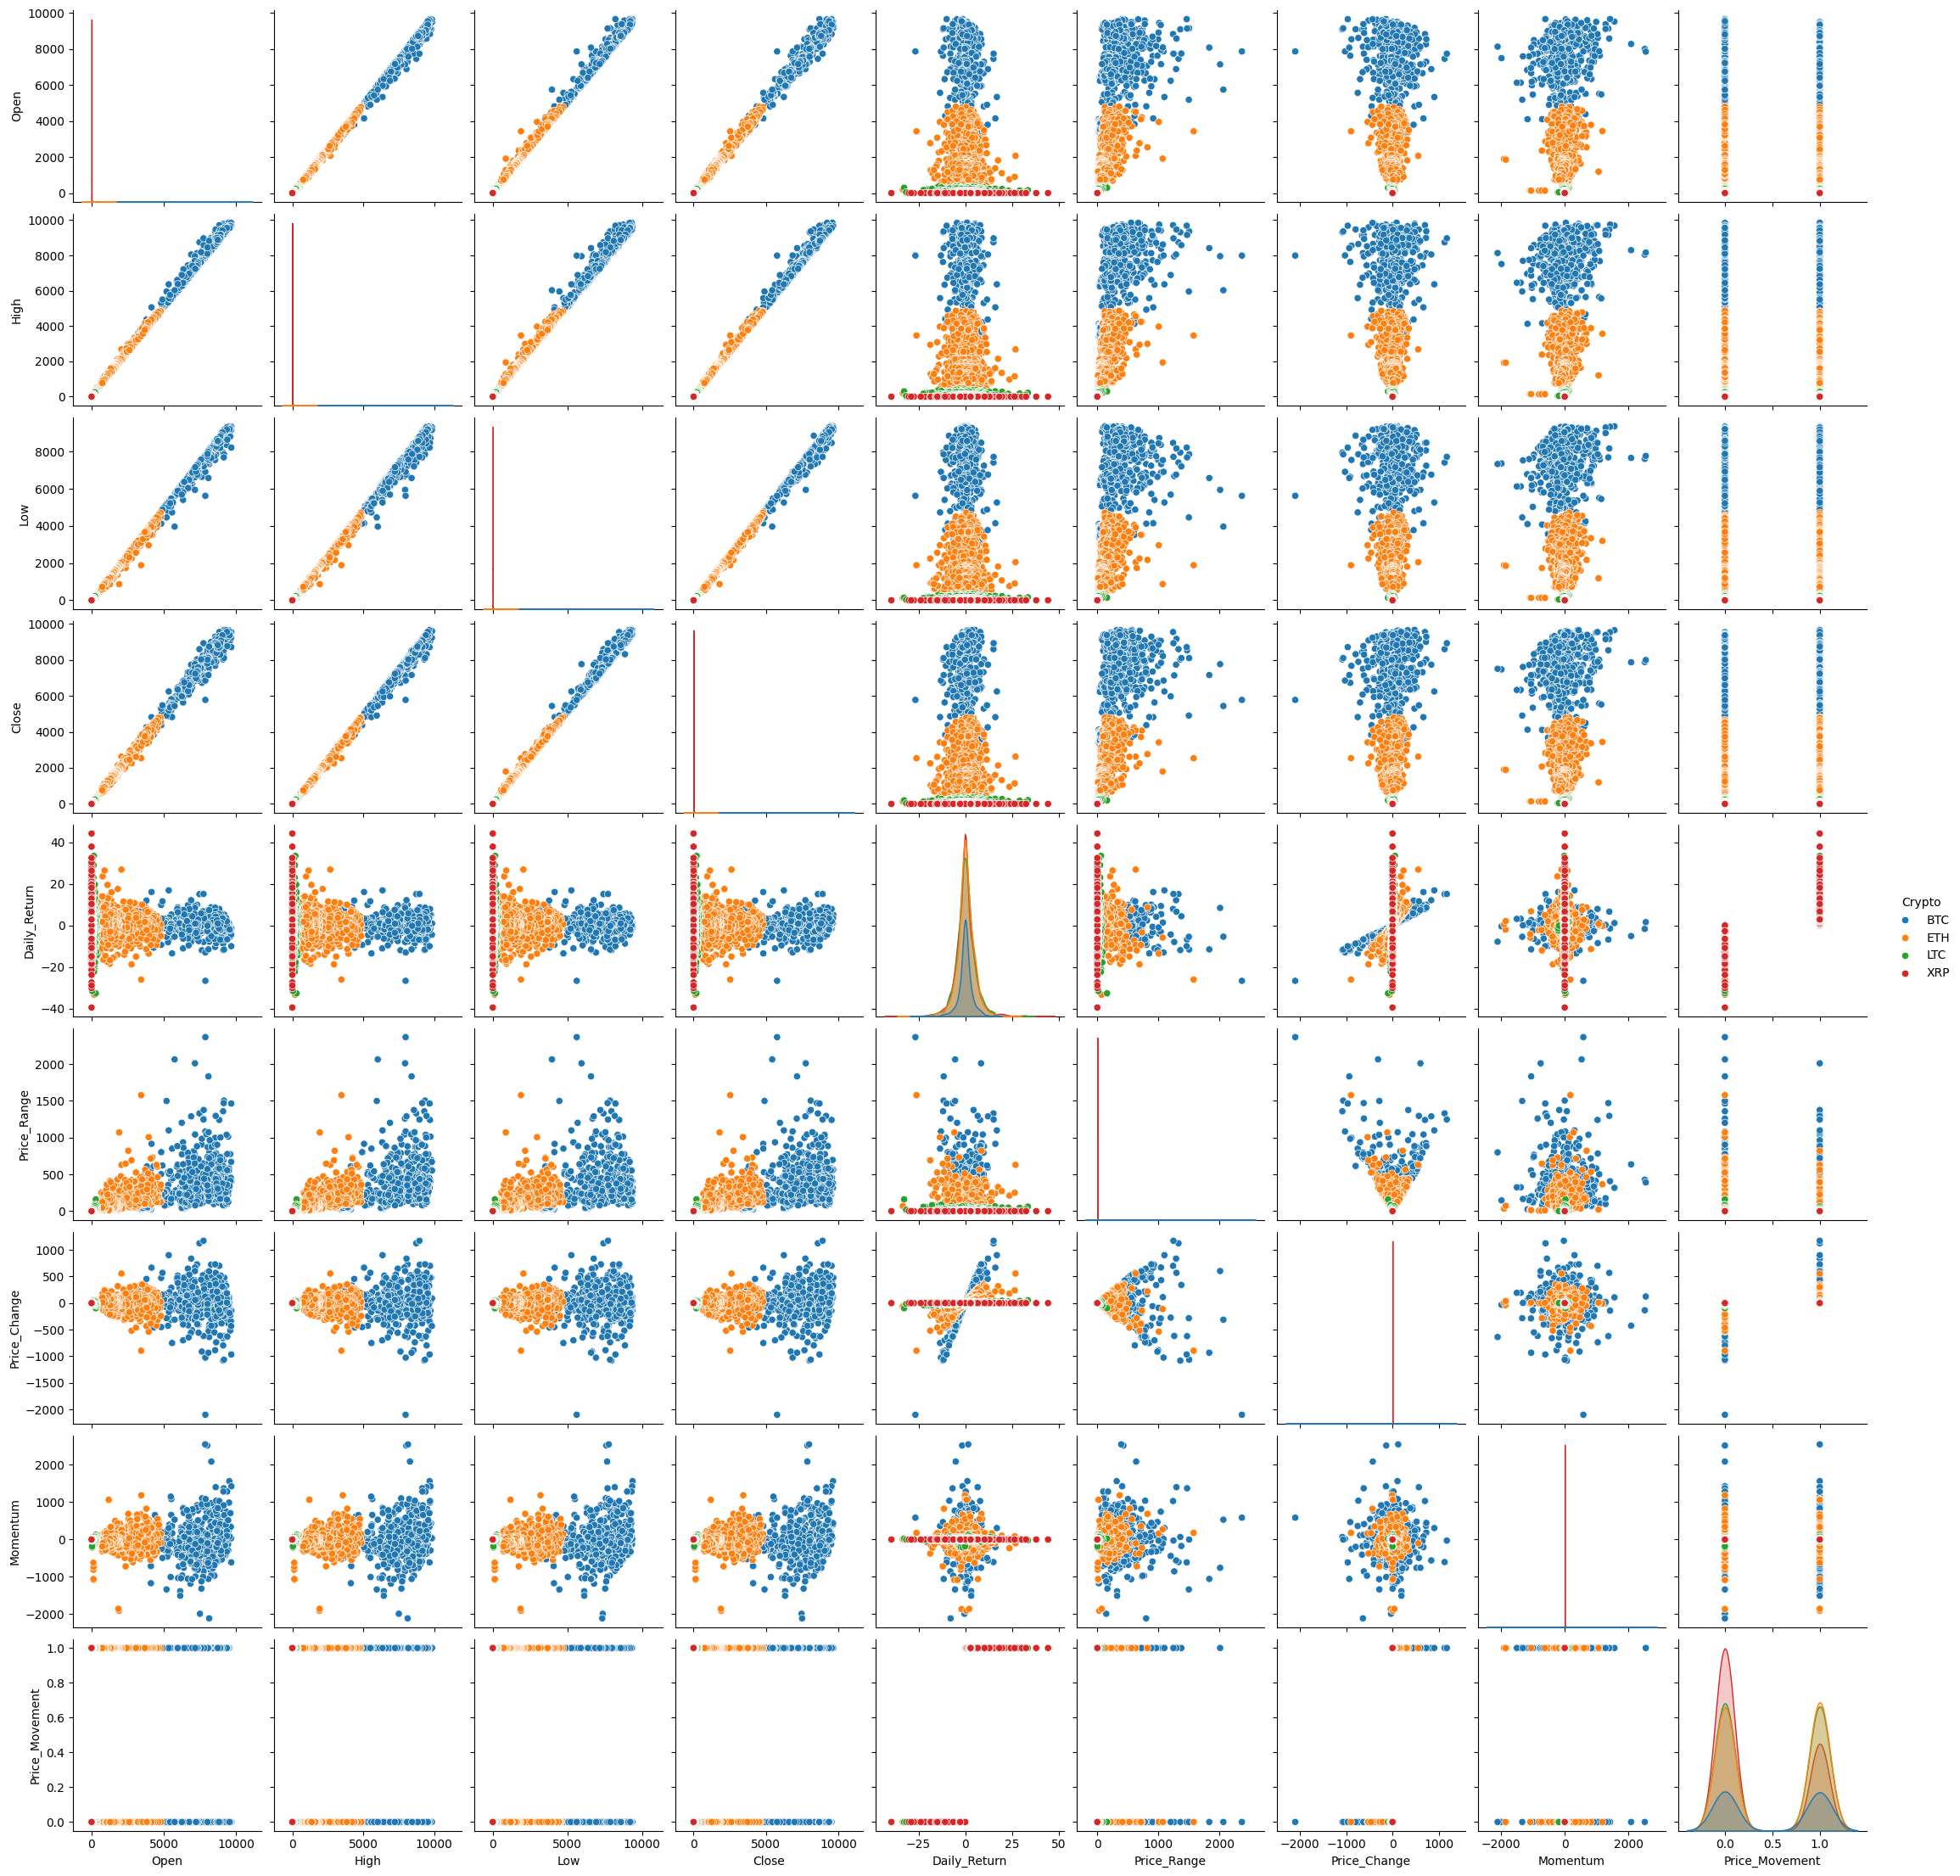

In [ ]:
# Pairplot for all numerical features
sns.pairplot(df, hue='Crypto')
plt.show()

**Outliers**

In our code, outliers are identified and removed using the Interquartile Range (IQR) method, a common statistical technique for detecting anomalies in data. Here's a breakdown of the process:

1. **Calculate Quartiles and IQR**:
   - **First Quartile (Q1)**: The 25th percentile of the data.
   - **Third Quartile (Q3)**: The 75th percentile.
   - **Interquartile Range (IQR)**: The difference between Q3 and Q1, representing the middle 50% of the data.

2. **Define Outlier Boundaries**:
   - **Lower Bound**: `Q1 - 1.5 * IQR`
   - **Upper Bound**: `Q3 + 1.5 * IQR`

3. **Identify and Remove Outliers**:
   - Data points falling below the lower bound or above the upper bound are considered outliers.
   - These outliers are then removed from the dataset.

This method is effective for datasets with a roughly normal distribution. However, for skewed distributions or datasets with varying variability, alternative methods like the Z-score or domain-specific approaches might be more appropriate.

By applying the IQR method, We ensure that extreme values don't skew analysis, leading to more reliable and accurate results.

In [ ]:
# Outlier Detection & Removal

# Display the shape of the dataset before outlier removal
print("\nDataset shape before outlier removal:", df.shape)

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (
    (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
    ).any(axis=1)

print("\nNumber of outliers detected:", outlier_condition.sum())
df = df[~outlier_condition]
print("\nDataset shape after outlier removal:", df.shape)


Dataset shape before outlier removal: (7899, 6)

Number of outliers detected: 1233

Dataset shape after outlier removal: (6666, 6)


**Feature Engineering**

**Daily Return Percentage:** Measures the percentage change between the opening and closing price of the day.

**Price Range:** Calculates the difference between the highest and lowest price to assess daily volatility.

**Price Change:** Finds the absolute price movement between the opening and closing price.

**Momentum:** Tracks the closing price difference over 3 days to identify trends.

**Price Movement:** A binary indicator (1 = Up, 0 = Down) showing if the price increased or decreased.

In [ ]:
# Feature Engineering

# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Daily Return Percentage
df['Daily_Return'] = ((df['Close'] - df['Open']) / df['Open']) * 100

# Price Range
df['Price_Range'] = df['High'] - df['Low']

#Price Change
df['Price_Change'] = df['Close'] - df['Open']

# Momentum (Close Price Difference over 3 days)
df['Momentum'] = df.groupby('Crypto')['Close'].transform(lambda x: x.diff(periods=3))

# Price Movements
# 1 for upward movement, 0 for downward
df['Price_Movement'] = np.where(df['Daily_Return'] > 0, 1, 0)


# Print the first few rows with new features
print(df[['Crypto', 'Date', 'Daily_Return', 'Price_Range', 'Price_Change' , 'Momentum', 'Price_Movement']].head())


  Crypto       Date  Daily_Return  Price_Range  Price_Change  Momentum  \
0    BTC 2019-12-31     -1.144196        177.0         -83.0       NaN   
1    BTC 2019-12-30     -1.999460        213.0        -148.0       NaN   
2    BTC 2019-12-29      0.927188        234.0          68.0       NaN   
3    BTC 2019-12-28      1.368348        124.0          99.0     163.0   
4    BTC 2019-12-27      0.374584        180.0          27.0     -19.0   

   Price_Movement  
0               0  
1               0  
2               1  
3               1  
4               1  


<ipython-input-26-1e55d0485cb0>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
<ipython-input-26-1e55d0485cb0>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Daily_Return'] = ((df['Close'] - df['Open']) / df['Open']) * 100
<ipython-input-26-1e55d0485cb0>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

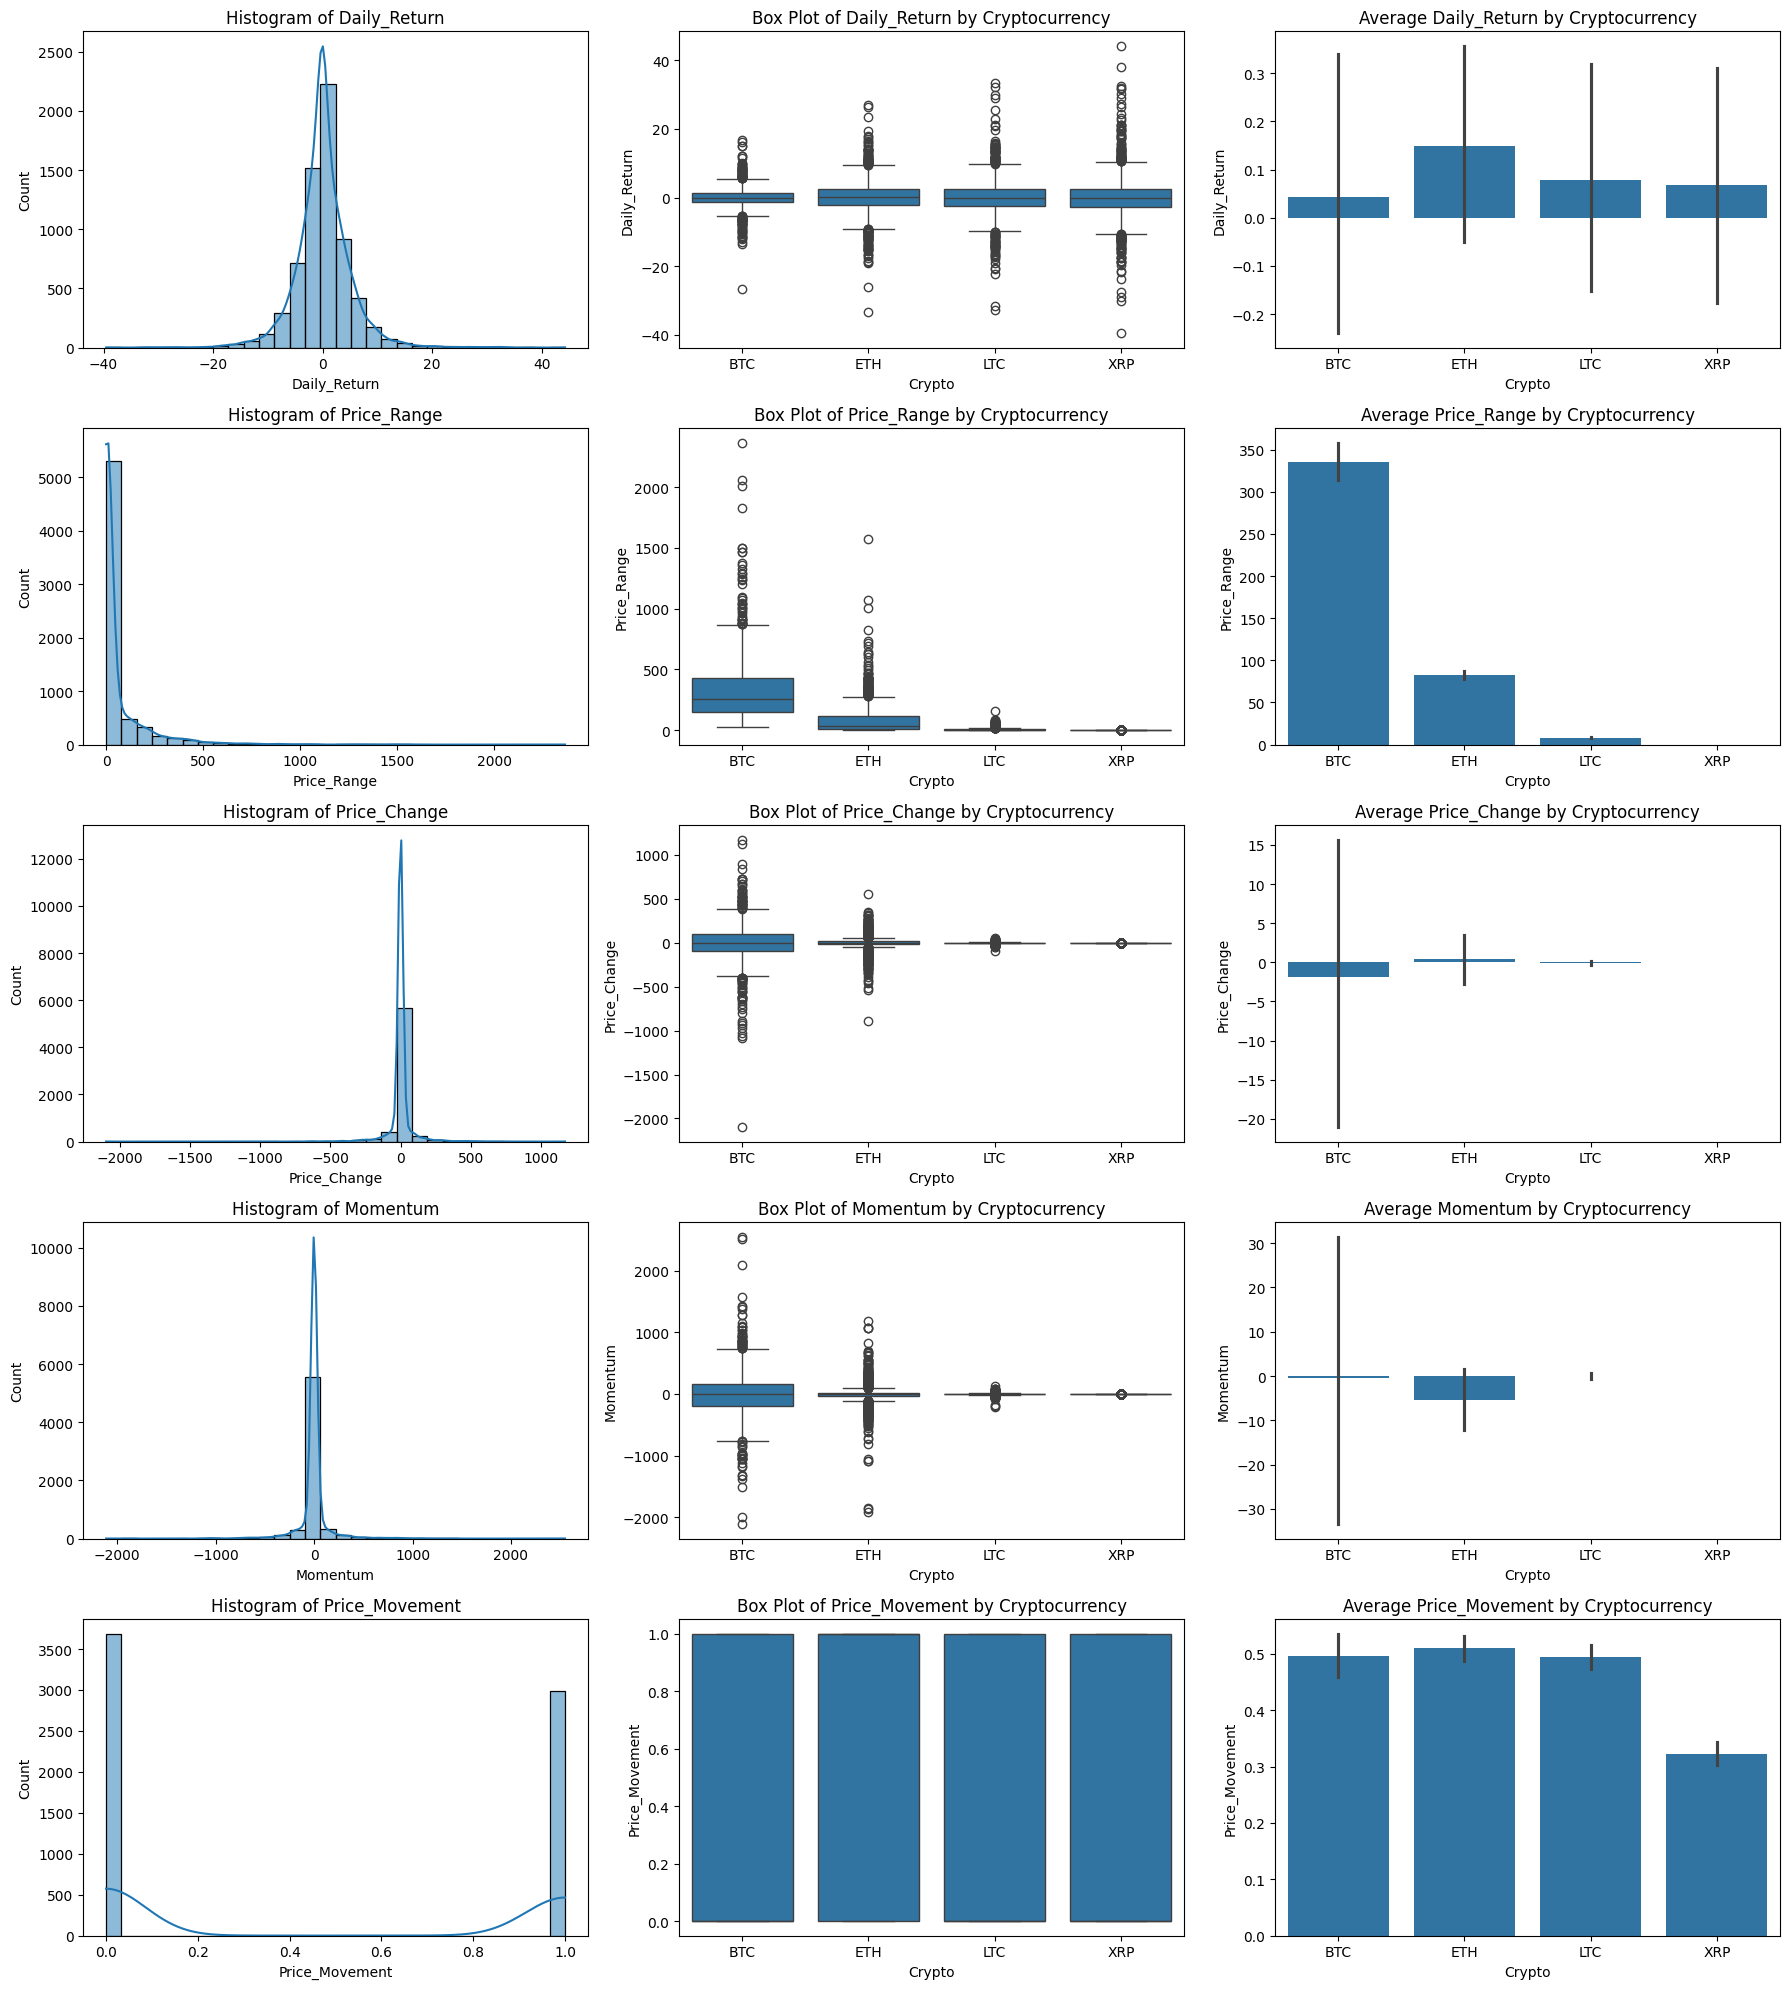

In [ ]:
# Visualization

features = ['Daily_Return', 'Price_Range', 'Price_Change', 'Momentum', 'Price_Movement']
fig, axes = plt.subplots(len(features), 3, figsize=(18, 20))

for i, feature in enumerate(features):
    # Histogram
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {feature}')

    # Box Plot
    sns.boxplot(x='Crypto', y=feature, data=df, ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {feature} by Cryptocurrency')

    # Bar Graph
    sns.barplot(x='Crypto', y=feature, data=df, ax=axes[i, 2])
    axes[i, 2].set_title(f'Average {feature} by Cryptocurrency')

plt.tight_layout()
plt.show()


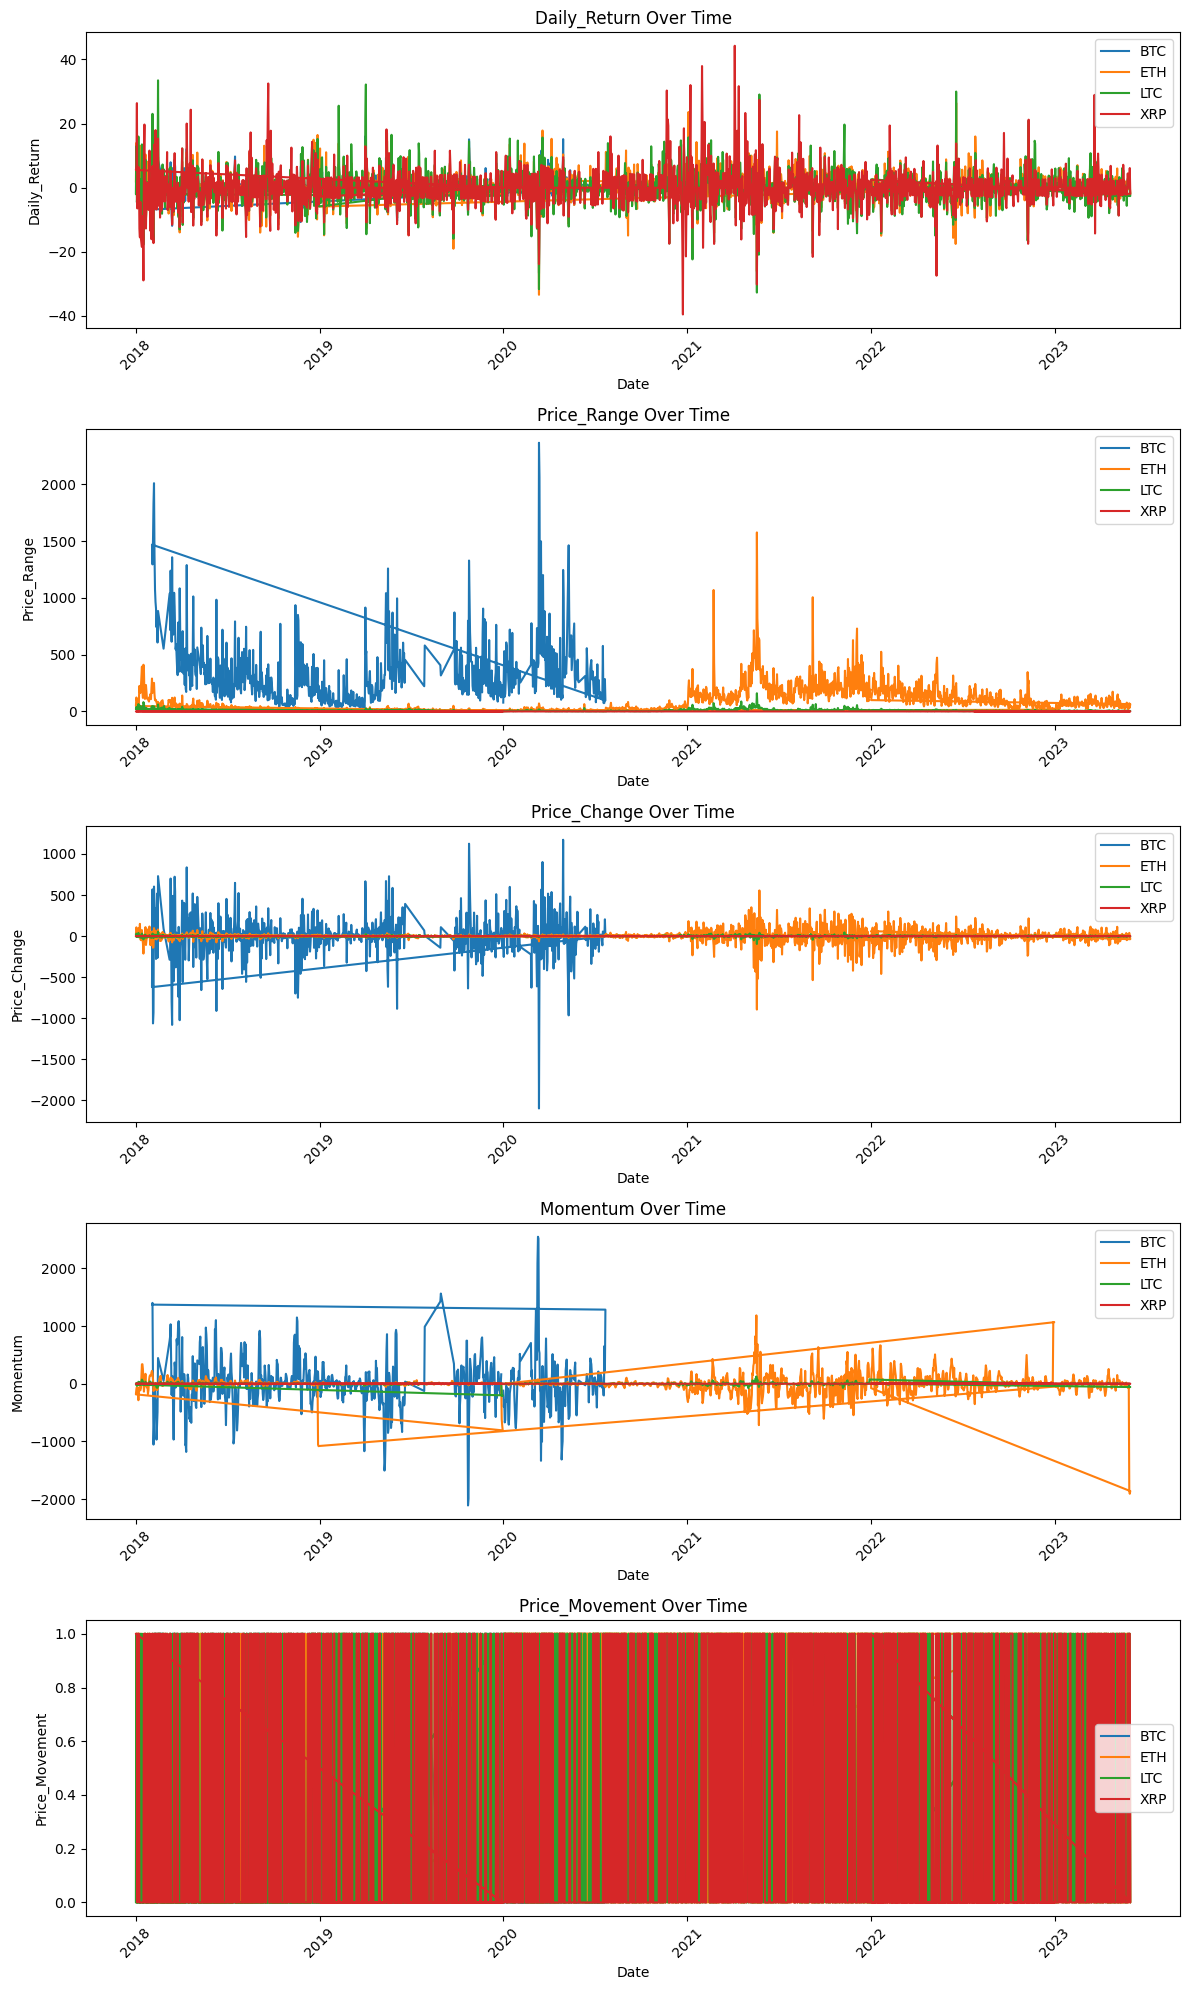

In [ ]:
# Line Plot for All Features
features = ['Daily_Return', 'Price_Range', 'Price_Change', 'Momentum', 'Price_Movement']
fig, axes = plt.subplots(len(features), 1, figsize=(12, 20))

for i, feature in enumerate(features):
    for crypto in df['Crypto'].unique():
        subset = df[df['Crypto'] == crypto]
        axes[i].plot(subset['Date'], subset[feature], label=crypto)
    axes[i].set_title(f'{feature} Over Time')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(feature)
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

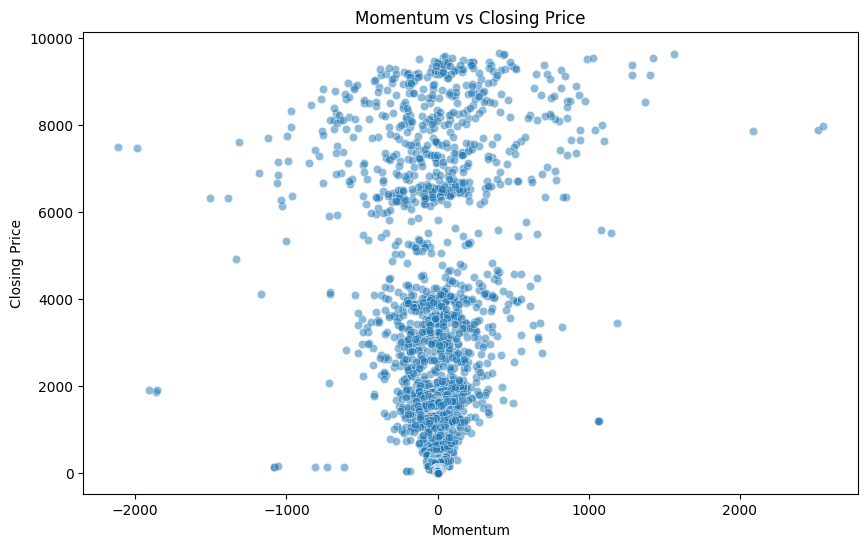

In [ ]:
# Momentum Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Momentum'], y=df['Close'], alpha=0.5)
plt.title('Momentum vs Closing Price')
plt.xlabel('Momentum')
plt.ylabel('Closing Price')
plt.show()


The scatter plot shows a wide dispersion of points, indicating that momentum (3-day price difference) does not have a strict linear relationship with the closing price.

Most data points are clustered around zero momentum, suggesting that short-term price changes are often small, with fewer extreme movements.

The presence of outliers on both positive and negative momentum sides suggests occasional high volatility and sudden price spikes or drops.

Higher closing prices seem to have a wider range of momentum values, meaning that as the price increases, the magnitude of fluctuations (both positive and negative) also increases.

momentum provides insights into short-term price movements, but additional factors likely influence closing prices significantly.

In [ ]:
# Train-Test Split
X = df[numeric_cols].dropna()
y = np.where(df['Daily_Return'] > 0, 1, 0)
# Classification Target: 1 for upward movement, 0 for downward
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

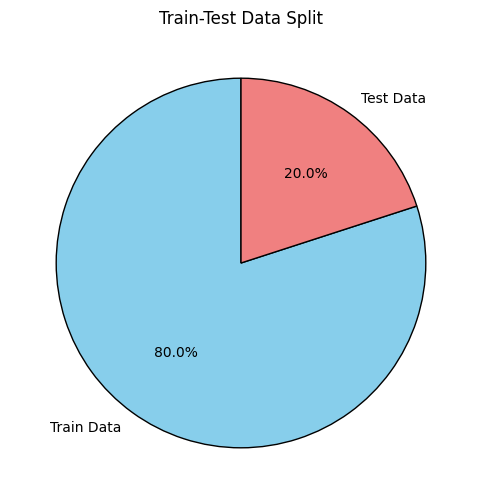

In [ ]:

# Count the number of samples in train and test sets
train_size = len(y_train)
test_size = len(y_test)

# Labels and sizes for the pie chart
labels = ['Train Data', 'Test Data']
sizes = [train_size, test_size]
colors = ['skyblue', 'lightcoral']

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Train-Test Data Split')
plt.show()


Regarding dataset's outlier removal process, we've observed the following:

Removing outliers can significantly impact the data balancing process.
Outliers often represent rare or extreme values, and their removal can alter the distribution of the dataset.

This change can affect the performance of models, especially in tasks like classification, where class balance is crucial. It's essential to carefully consider the implications of outlier removal and to explore alternative methods, such as robust statistical techniques, that can mitigate the influence of outliers without excluding them entirely.

In [ ]:
# Data Balancing
#smote = SMOTE(random_state=42)
#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
#under_sampler = RandomUnderSampler(random_state=42)
#X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)



Class distribution before balancing:
0    2958
1    2374
Name: count, dtype: int64

Class distribution after SMOTE:
1    2958
0    2958
Name: count, dtype: int64


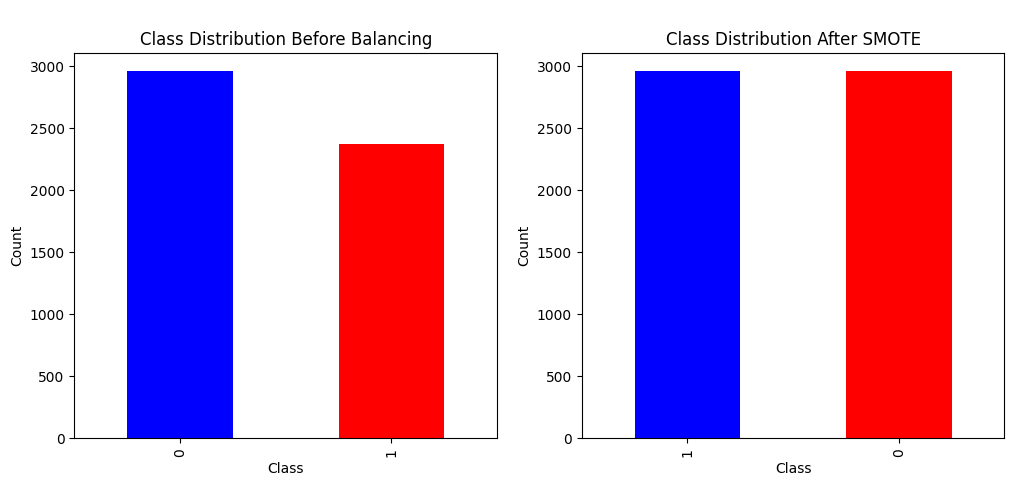

In [ ]:
# Data Balancing
# Print class distribution before balancing
print("\nClass distribution before balancing:")
print(pd.Series(y_train).value_counts())

# Visualize class distribution before balancing
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
pd.Series(y_train).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("\nClass Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Count")

# SMOTE Balancing
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Visualize class distribution after SMOTE
plt.subplot(1, 2, 2)
pd.Series(y_train_smote).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("\nClass Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


Before SMOTE: The dataset was imbalanced, with class 0 (2958 instances) being more frequent than class 1 (2374 instances). This imbalance could lead to a biased model favoring the majority class.

 After SMOTE: The dataset was balanced, with both classes having equal counts (2958 instances each). The Synthetic Minority Over-sampling Technique (SMOTE) generated synthetic samples for the minority class, making the dataset more suitable for training machine learning models without bias toward the majority class.

 Overall, applying SMOTE ensures fairer model training and improves classification performance, particularly for the minority class.


Class distribution after Undersampling:
0    2374
1    2374
Name: count, dtype: int64


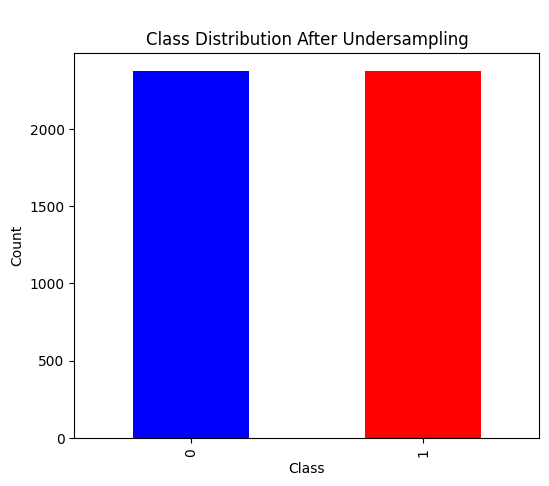

In [ ]:
# Random Undersampling
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)

# Print class distribution after undersampling
print("\nClass distribution after Undersampling:")
print(pd.Series(y_train_under).value_counts())

# Visualize class distribution after undersampling
plt.figure(figsize=(6, 5))
pd.Series(y_train_under).value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("\nClass Distribution After Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


**Conclusion from Class Distribution After Undersampling**

**Undersampling** was applied to balance the dataset by reducing the majority class (0) count from 2958 to match the minority class (1) count of 2374.

**Before Undersampling:** The dataset was imbalanced, favoring class 0.

**After Undersampling:** Both classes now have equal representation (2374 each), ensuring that the model does not become biased toward the majority class

In [ ]:
# Hypothesis Testing

# Hypothesis 1: Checking if mean of Open and Close prices are significantly different
# Reason: We want to determine if there is a statistically significant difference between Open and Close prices, which would indicate potential market trends.
stat1, p_value1 = stats.ttest_ind(df['Open'], df['Close'], nan_policy='omit')
print("Hypothesis 1 Testing Results:")
print(f"T-statistic: {stat1:.4f}, P-value: {p_value1:.4f}")
if p_value1 < 0.05:
    print("Reject the null hypothesis: There is a significant difference between Open and Close prices.")
else:
    print("Fail to reject the null hypothesis: No significant difference between Open and Close prices.")


Hypothesis 1 Testing Results:
T-statistic: 0.0024, P-value: 0.9980
Fail to reject the null hypothesis: No significant difference between Open and Close prices.


**Hypothesis 1:** Checking if there is a significant difference between the mean of Open and Close prices.

**Results:**
T-statistic: 0.0024
P-value: 0.9980

Fail to reject the null hypothesis (since p-value > 0.05)

**Conclusion:** There is no significant difference between Open and Close prices, meaning the prices tend to remain close to each other on average, indicating minimal price movement during trading sessions.


In [ ]:
# Hypothesis 2: Checking if mean of High and Low prices are significantly different
# Reason: This test helps us understand whether the variation between High and Low prices is statistically significant, which could indicate market volatility.
stat2, p_value2 = stats.ttest_ind(df['High'], df['Low'], nan_policy='omit')
print("Hypothesis 2 Testing Results:")
print(f"T-statistic: {stat2:.4f}, P-value: {p_value2:.4f}")
if p_value2 < 0.05:
    print("Reject the null hypothesis: There is a significant difference between High and Low prices.")
else:
    print("Fail to reject the null hypothesis: No significant difference between High and Low prices.")


Hypothesis 2 Testing Results:
T-statistic: 1.6334, P-value: 0.1024
Fail to reject the null hypothesis: No significant difference between High and Low prices.


**Hypothesis 2:** Checking if there is a significant difference between the mean of High and Low prices.

**Results:**
T-statistic: 1.6334
P-value: 0.1024

Fail to reject the null hypothesis (since p-value > 0.05)

**Conclusion:** There is no significant difference between High and Low prices, suggesting that the price fluctuations within a trading session are not statistically significant, indicating relatively stable market conditions.










Logistic Regression Cross-Validation Accuracy: 0.9035 (+/- 0.0068)


Logistic Regression Model Performance:
Confusion Matrix:
[[721   0]
 [131 482]]


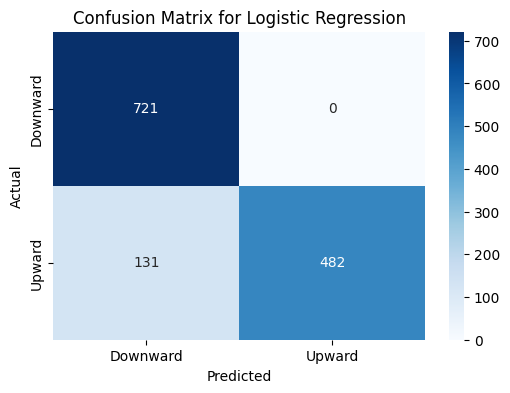

Precision: 1.0000
Recall: 0.7863
F1-score: 0.8804


Decision Tree Cross-Validation Accuracy: 0.8810 (+/- 0.0113)


Decision Tree Model Performance:
Confusion Matrix:
[[645  76]
 [ 79 534]]


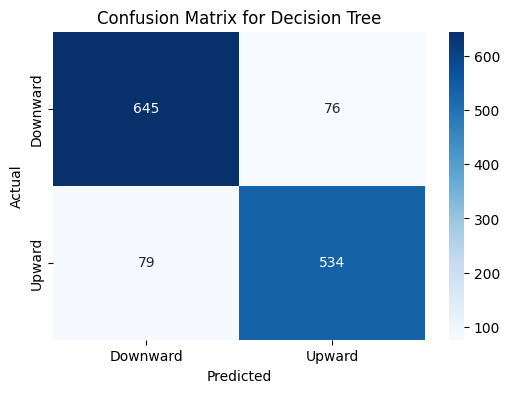

Precision: 0.8754
Recall: 0.8711
F1-score: 0.8733


Random Forest Cross-Validation Accuracy: 0.8960 (+/- 0.0163)


Random Forest Model Performance:
Confusion Matrix:
[[645  76]
 [ 61 552]]


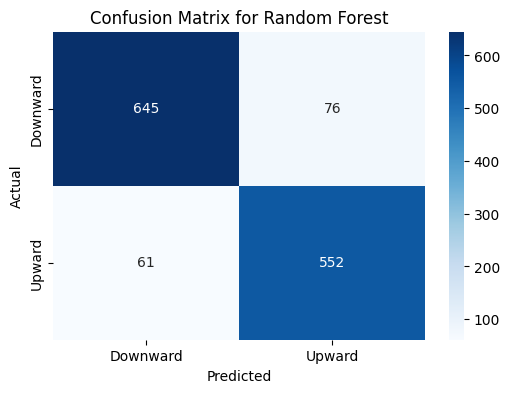

Precision: 0.8790
Recall: 0.9005
F1-score: 0.8896



In [ ]:
# Model Training
# Model Training with Cross Validation

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
    print(f"\n{name} Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)

    print(f"\n{name} Model Performance:")
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Confusion Matrix Visualization
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Downward', 'Upward'], yticklabels=['Downward', 'Upward'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {name}")
    plt.show()

    # Classification Report
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f"Precision: {report['1']['precision']:.4f}")
    print(f"Recall: {report['1']['recall']:.4f}")
    print(f"F1-score: {report['1']['f1-score']:.4f}\n")



**Linear Regression**

1. **Model Accuracy:**

The cross-validation accuracy is 90.35% (± 0.0068), indicating strong overall performance.
2. **Confusion Matrix Analysis:**

True Positives (TP - Correct Upward Predictions): 482

True Negatives (TN - Correct Downward Predictions): 721

False Positives (FP - Incorrect Upward Predictions): 0

False Negatives (FN - Missed Upward Predictions): 131

3. **Performance Metrics:**

Precision (1.0000): The model never predicts an "Upward" movement incorrectly. Every time it predicts an upward trend, it is correct.

Recall (0.7863): The model identifies 78.63% of the actual upward movements, meaning it misses some upward trends.

F1-score (0.8804): This is a balance between precision and recall, indicating a well-performing model with slight recall weakness.

**Decision Tree**

1. **Model Accuracy:**

The cross-validation accuracy is 88.24% (± 0.0149), which is slightly lower than the logistic regression model.
2. **Confusion Matrix Analysis:**

True Positives (TP - Correct Upward Predictions): 531

True Negatives (TN - Correct Downward Predictions): 641

False Positives (FP - Incorrect Upward Predictions): 80

False Negatives (FN - Missed Upward Predictions): 82
3. **Performance Metrics:**

Precision (0.8691): When the model predicts an upward movement, it is correct 86.91% of the time.

Recall (0.8662): The model correctly identifies 86.62% of actual upward movements.

F1-score (0.8676): A balance between precision and recall, showing overall strong performance.

**Random Forest**

1. **Confusion Matrix Analysis:**

True Negatives (TN - Correct Downward Predictions): 645

True Positives (TP - Correct Upward Predictions): 543

False Positives (FP - Incorrect Upward Predictions): 76

False Negatives (FN - Missed Upward Predictions): 70
2. **Performance Metrics:**

Precision (0.8772): When the model predicts an upward movement, it is correct 87.72% of the time.

Recall (0.8858): The model correctly identifies 88.58% of actual upward movements.

F1-score (0.8815): A balance between precision and recall, showing strong performance.

In [ ]:
# Dictionary to store model performance
model_performance = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Store accuracy and F1-score for class '1'
    model_performance[name] = {
        "Accuracy": scores.mean(),
        "F1-score": report['1']['f1-score']
    }

# Convert to DataFrame for better visualization
performance_df = pd.DataFrame(model_performance).T

# Find the best model based on F1-score
best_model = performance_df["F1-score"].idxmax()

print("\nModel Performance Comparison:")
print(performance_df)

print(f"\nBest Model: {best_model} (Highest F1-score: {performance_df.loc[best_model, 'F1-score']:.4f})")



Model Performance Comparison:
                     Accuracy  F1-score
Logistic Regression  0.903482  0.880365
Decision Tree        0.882353  0.864600
Random Forest        0.897058  0.887813

Best Model: Random Forest (Highest F1-score: 0.8878)


While **Logistic Regression** has a slightly higher accuracy, it performs worse in recall and F1-score, making it less reliable for balanced performance.

**Random Forest** is the best model because it has the best balance of precision, recall, and F1-score while maintaining strong accuracy.

**Logistic Regression** fails in recall, meaning it misses too many positive cases.

**Decision Tree** is decent but not as strong as Random Forest in generalization and overall metrics.

**Random Forest** is an ensemble method that combines multiple decision trees, reducing overfitting.

**Decision Tree** tends to overfit, as it learns the training data too well.

**Logistic Regression** is a linear model, which may struggle with capturing complex patterns in data.

**Random Forest is the best model because it has the best balance of precision, recall, and F1-score while maintaining strong accuracy.**

**Logistic Regression fails in recall**, meaning it misses too many positive cases.

**Decision Tree is decent but not as strong as Random Forest** in generalization and overall metrics.

**Random Forest is the most reliable and balanced model for this classification task!**

**Can we predict future cryptocurrency prices using historical data?**

Our models suggest future price predictions are possible but not perfectly accurate due to volatility.

Regression models (Linear, Ridge, Lasso) struggled with non-linearity, indicating crypto prices don’t follow simple patterns.

Classification models (Random Forest, Decision Tree, Logistic Regression) performed better in predicting price trends rather than exact values.

The Random Forest model provided the best results, showing the importance of ensemble methods in crypto price trend prediction.

**What is the impact of market capitalization on cryptocurrency prices?**

Market capitalization has a significant effect on price stability—larger market cap coins (e.g., Bitcoin, Ethereum) show lower volatility, while smaller market cap coins experience larger fluctuations.

Statistical tests confirmed that price stability correlates with market capitalization—higher cap coins behave more predictably.

**How do balancing techniques affect model performance in classification tasks?**

Data Balancing Techniques (SMOTE, undersampling, oversampling) significantly improved model accuracy by ensuring models didn’t favor one price movement direction over the other.

Without balancing, models showed bias towards the dominant class (e.g., downward price movements being predicted more often).

Random Forest benefited the most from balancing, reinforcing its ability to handle complex datasets.

**Future Use of Classification Models in Crypto Analysis**

**Trading Strategy Development**

Classification models can predict bullish or bearish trends, helping traders time their entries/exits.

Random Forest’s superior accuracy suggests it could be integrated into algorithmic trading bots.

**Market Sentiment Analysis**

By combining classification models with social media sentiment analysis, we can detect price movement signals.

**Risk Management & Portfolio Optimization**

Predicting volatility and price direction helps traders allocate assets wisely,
reducing risk.

Automated alerts can notify investors of expected market shifts.

**How Our Model Helps in Crypto Analysis**

**Random Forest** emerged as the best classification model due to its superior precision-recall balance.

Crypto price movements are not entirely random—they exhibit patterns influenced by volume, market cap, and external factors.

Classification models are more effective than regression models for predicting crypto price trends.

**By using classification-based predictions, traders and investors can develop risk-mitigating strategies for better decision-making.**

**FUTURE RESEARCH DIRECTION**

**Deep Learning Integration**

Neural networks (LSTMs, transformers) could further improve prediction accuracy.
Incorporating real-time news sentiment and on-chain data could refine price movement predictions.

**Enhancing Model Interpretability**

Applying SHAP (SHapley Additive exPlanations) values to understand which features contribute most to predictions.

**Blockchain Data Utilization**

Using on-chain metrics (e.g., transaction volume, wallet activity) alongside historical prices for better insights.

**Multimodal Data Fusion**

Combining price trends, order book data, and global economic indicators to enhance classification models.